# Content and Objective

+ Show effect of analog-digital conversion
+ Apply sampling as well as qunyatization of amplitude and show it

# Importing and Plotting Options

In [7]:
import numpy as np

from scipy import signal

import matplotlib
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive
import ipywidgets
from ipywidgets import FloatSlider, IntSlider, VBox, interactive_output
from IPython.display import clear_output

%matplotlib inline

In [8]:
# plotting options 
font = {'size'   : 20}
plt.rc('font', **font)
plt.rc('text', usetex=True)

matplotlib.rc('figure', figsize=(18, 6) )

In [9]:
# "internal" continuous sample time used for getting "analog signals
t_cont = 0.01 

# set time resp. pulse interval and related parameters
t_min = -0.0
t_max = 10.0

t = np.arange(t_min, t_max+t_cont, t_cont)

# switch for choosing the function
switch = 1

In [10]:
# choose functions by applying switch
def my_fct( switch ):

    if switch == 1:
        
        # define random polynomial by randomly sampling polynomial order and coefficients --> being part of first random function
        N_max = 15
        N = 3 + np.random.randint( N_max )

        coeffs = np.random.rand( N ) * (-1)**np.random.randint( 2, size=N)

        fct = np.polynomial.polynomial.Polynomial( coeffs )
        
    elif switch == 2:
        
        # define random polynomial by randomly sampling polynomial order and coefficients --> being part of first random function
        N_max = 15
        N = 3 + np.random.randint( N_max )

        coeffs = np.random.rand( N ) * (-1)**np.random.randint( 2, size=N)
        poly = np.polynomial.polynomial.Polynomial( coeffs )
        
        # get random function by randomly cascading 4 functions 
        # get sum of two sine functions
        functions = [ np.sin, np.arcsin, np.sqrt, np.exp, np.i0, np.sinh, np.arcsinh, np.sinc, poly]

        fct = np.random.choice( functions, 4)
        
    elif switch == 3:
        
        # second signal being composed of two sinusoids    
        fct = np.sin( 14 * np.pi * t ) + np.sin( 32 * np.pi * t )
        
    return fct

fct = my_fct( switch )
 

In [11]:
# get samples of the function
def get_samples( fct, t_s, switch ):
    
    t_sampled = np.arange(t_min, t_max + t_s, t_s )

    if switch == 1 or switch == 3:
        x = fct( t ) 
        x_sampled = fct( t_sampled )

    elif switch == 2:
        x = t
        x_sampled = t_sampled

        for f in fct:
            x = f( x )
            x[ np.isnan( x ) ] = 0
            x[ np.isinf( x ) ] = 0
            
            x_sampled = f( x_sampled )
            x_sampled[ np.isnan( x_sampled ) ] = 0
            x_sampled[ np.isinf( x_sampled ) ] = 0

    return t, x, t_sampled, x_sampled
    

### plotting

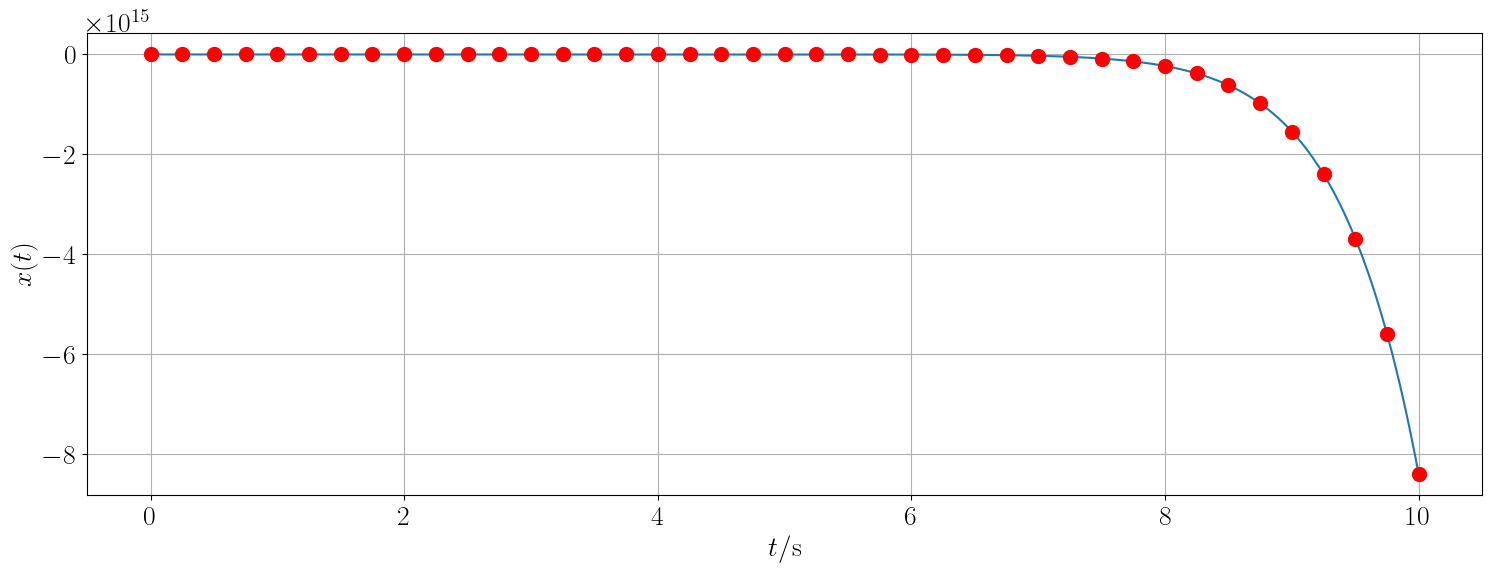

In [12]:
# init figure
fig, ax = plt.subplots()

line1, = ax.plot([], [])
line2, = ax.plot([], [], 'ro', markersize=10)

ax.grid(True)
ax.set_xlabel('$t/\\mathrm{s}$')
ax.set_ylabel('$x(t)$')

# plotting function
def plot_function( t_s ):


    t, x, t_sampled, x_sampled = get_samples(fct, t_s, switch)

    line1.set_data(t, x)
    line2.set_data(t_sampled, x_sampled)

    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

t_s_slider = FloatSlider(min=t_cont, max=.5, step=0.01, value=.25)

out = interactive_output(plot_function, {
    't_s': t_s_slider,
})

display(VBox([t_s_slider, out]))

# 👇 IMPORTANT: initial call
plot_function(t_s_slider.value)